# marv-hyena round 3: measuring at the bottleneck

Round 2 ([RESEARCH_LOG.md](https://github.com/thebnbrkr/marv-hyena/blob/main/RESEARCH_LOG.md)) established:
- **Block 30 is the only thing the output sees.** Its write is ~123,000× every other write, so in bf16 everything
  written earlier is rounded away, and block 31 does literally nothing.
- **Five load-bearing layers** (L0, L1, L9, L29, L30): removing any one alone breaks the model. Every Hyena family
  contains one, which is why family ablations kept breaking the model.

Round 3:
| step | question |
|---|---|
| R3.1 | Is block 30's size a property of the weights or of bf16 arithmetic? (float32 recomputation) |
| R3.2 | Re-find the load-bearing layers on this run (health of every single-mixer ablation) |
| R3.3 | **Fair family tests**: switch off each family *but keep the load-bearing layers on*. Does LI copy? Carry context? Codon rhythm? |
| R3.4 | **What does block 30 read?** Integrated-gradients attribution at block 30's input, by block and by distance |
| R3.5 | **Where does a mutation's signal go?** Swap the whole residual at the mutation site after each block |
| R3.6 | Are start/stop codons special in block 0? Rank all 64 three-letter words; total-effect position importance |

**Runtime:** A100 + High-RAM.

## 0. Setup

In [1]:
# GPU check (no torch import yet: the install below may change the torch version)
!nvidia-smi --query-gpu=name,memory.total,compute_cap --format=csv

name, memory.total [MiB], compute_cap
NVIDIA A100-SXM4-80GB, 81920 MiB, 8.0


In [2]:
# OPTIONAL: keep the ~15 GB Evo 2 weights on Google Drive so the next session skips the download.
# This must run BEFORE anything imports huggingface_hub / evo2.
USE_DRIVE = False

import os
if USE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'
    os.makedirs(os.environ['HF_HOME'], exist_ok=True)
print('HF_HOME =', os.environ.get('HF_HOME', '(default ~/.cache/huggingface)'))

HF_HOME = (default ~/.cache/huggingface)


In [3]:
# Install Evo 2 + marv-hyena (~2-5 min). NO flash-attn: pip usually finds no prebuilt wheel for Colab's torch
# and compiles for hours. marv-hyena instead runs Evo 2's attention through PyTorch's built-in fused kernel
# (scaled_dot_product_attention), which is also fast on an A100 -- see marv_hyena/noflash.py.
# Colab runs Python 3.13, but every current evo2 release declares Python < 3.13, so a plain `pip install evo2`
# silently falls back to the old, incompatible 0.3.0. evo2 is pure Python, so force the current release.
# Colab also ships an empty `transformer-engine` package whose import crashes evo2; remove it (7B needs no TE).
!pip uninstall -y -q transformer-engine transformer_engine
!pip install -q --ignore-requires-python evo2==0.6.0
!rm -rf marv-hyena && git clone -q https://github.com/thebnbrkr/marv-hyena.git
!pip install -q -r marv-hyena/requirements.txt openpyxl

import sys
sys.path.insert(0, '/content/marv-hyena')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.9/42.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.4/6.4 MB 75.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 49.9 MB/s eta 0:00:00


In [4]:
# Must run before anything imports evo2/vortex: lets Vortex import without flash-attn and turns flash attention off.
from marv_hyena import noflash
noflash.prepare()

import torch, vortex, evo2
from importlib.metadata import version
print('evo2', version('evo2'), '| vtx', version('vtx'))
assert version('evo2') >= '0.6.0', 'old evo2 installed: Runtime -> Disconnect and delete runtime, then rerun from the top'
print('torch', torch.__version__, '| cuda', torch.version.cuda, '| flash-attn package installed:', noflash.flash_attn_available())
print('GPU', torch.cuda.get_device_name(0), 'capability', torch.cuda.get_device_capability(0))
assert torch.cuda.get_device_capability(0)[0] >= 8, 'needs an Ampere+ GPU with bf16 (A100 / L4 / H100)'

evo2 0.6.0 | vtx 1.1.0
torch 2.11.0+cu130 | cuda 13.0 | flash-attn package installed: False
GPU NVIDIA A100-SXM4-80GB capability (8, 0)


In [5]:
# marv-hyena's own tests (a tiny CPU model that mirrors Vortex). Should say "35 passed".
!cd marv-hyena && python -m pytest -q

.....................................                                    [100%]
37 passed in 5.30s


In [6]:
# Data: the annotated E. coli K-12 genome from the evo2 repo
import os, urllib.request
os.makedirs('data', exist_ok=True)
EVO2_RAW = 'https://raw.githubusercontent.com/ArcInstitute/evo2/main/notebooks'
GENOME = 'data/NC_000913.gb'
if not os.path.exists(GENOME):
    urllib.request.urlretrieve(f'{EVO2_RAW}/sparse_autoencoder/NC_000913.gb', GENOME)

import marv_hyena as mh
from marv_hyena.probes import load_sequence
genome = load_sequence(GENOME)
print(f'E. coli genome: {len(genome):,} letters')

E. coli genome: 4,641,652 letters


In [7]:
# Load Evo 2 7B (downloads ~15 GB the first time)
import time
MODEL_NAME = 'evo2_7b'
t0 = time.time()
hm = mh.HyenaModel.load(MODEL_NAME)
print(f'loaded in {time.time()-t0:.0f}s')
print(hm.describe())
RESULTS = {}

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Found complete file in repo: evo2_7b.pt


/usr/local/lib/python3.13/dist-packages/evo2/models.py:294: UserWarning: Transformer Engine not installed. Falling back to bf16 projections (use_fp8_input_projections=False). 
  warnings.warn(


  0%|          | 0/32 [00:00<?, ?it/s]

 12%|█▎        | 4/32 [00:00<00:01, 25.56it/s]

100%|██████████| 32/32 [00:00<00:00, 120.05it/s]


Extra keys in state_dict: {'blocks.7.projections._extra_state', 'blocks.10.mixer.attn._extra_state', 'blocks.1.projections._extra_state', 'blocks.20.projections._extra_state', 'blocks.8.projections._extra_state', 'blocks.27.mixer.mixer.filter.t', 'blocks.21.projections._extra_state', 'blocks.19.projections._extra_state', 'blocks.24.mixer.attn._extra_state', 'unembed.weight', 'blocks.4.projections._extra_state', 'blocks.23.projections._extra_state', 'blocks.26.projections._extra_state', 'blocks.17.mixer.dense._extra_state', 'blocks.16.projections._extra_state', 'blocks.31.mixer.dense._extra_state', 'blocks.20.mixer.mixer.filter.t', 'blocks.2.projections._extra_state', 'blocks.16.mixer.mixer.filter.t', 'blocks.13.mixer.mixer.filter.t', 'blocks.22.projections._extra_state', 'blocks.14.projections._extra_state', 'blocks.30.projections._extra_state', 'blocks.13.projections._extra_state', 'blocks.28.projections._extra_state', 'blocks.11.projections._extra_state', 'blocks.6.projections._extra

In [8]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, json
from marv_hyena import diagnostics, motifs, interface
from marv_hyena.checks import run_smoke_checks
from marv_hyena.experiments import make_conditions, copy_test, codon_test, context_test, periodicity, summarize_copy

seq = genome[100_000:104_096]
assert run_smoke_checks(hm, seq), 'smoke checks failed: stop here'
HEALTH_SEQ = genome[300_000:304_096]
BOTTLENECK = diagnostics.find_bottlenecks(hm, seq, [1000, 2000, 4095])
print('bottleneck:', BOTTLENECK, '| baseline health:', diagnostics.health(hm, HEALTH_SEQ))
L = BOTTLENECK[0] if BOTTLENECK else hm.n_blocks - 2   # evo2_7b: block 30
print('interface block:', L)
RESULTS = {'bottleneck': BOTTLENECK, 'interface_block': L}

[PASS] embed + sum(writes) == final residual  rel_err=8.21e-06
[PASS] trace rows sum to real logit diff  sum=+8.541 actual=+8.505
[PASS] distance bands reconstruct block 14 (se)  rel_err=3.98e-03
[PASS] distance bands reconstruct block 15 (mr)  rel_err=3.41e-03
[PASS] distance bands reconstruct block 16 (li)  rel_err=2.66e-03
[PASS] block 0 receptive field small enough to enumerate  measured 9 letters
[PASS] hooks removed after intervention  
[PASS] mean-ablating LI mixers changes the output  

8/8 checks passed
bottleneck: [30] | baseline health: {'health_acc': 0.6959707140922546, 'health_lp': -0.6843298673629761, 'broken': False}
interface block: 30


## R3.1 Weights or arithmetic?

Recompute block 30's mixer write in **float32** from the same input. If the norm is the same (~10¹²), the blow-up comes
from the weights, not from bf16 rounding. Then recompute the logits in float32 with and without every earlier write:
if the change is ~0, earlier writes don't matter **even at full precision**.

In [9]:
prec = []
for start in (100_000, 1_000_000, 3_000_000):
    r = diagnostics.precision_check(hm, genome[start:start + 4096], block=L)
    r['region'] = start; prec.append(r)
RESULTS['precision'] = prec
pd.DataFrame(prec)

,norm_bf16,norm_fp32,norm_input_residual,logit_change_from_earlier_writes_fp32,logit_scale,region
0,6.418244e+11,6.393711e+11,5062605.5,0.000022,11.645988,100000
1,2.211555e+12,2.210419e+12,9241174.0,0.000018,23.102114,1000000
2,1.752468e+12,1.761152e+12,8392359.0,0.000011,24.021639,3000000


## R3.2 Load-bearing layers (re-found on this run)

In [10]:
lb = diagnostics.find_load_bearing(hm, HEALTH_SEQ)
LOAD_BEARING = [r['block'] for r in lb if r['broken']]
print('load-bearing mixers (removal alone breaks the model):', LOAD_BEARING)
RESULTS['load_bearing'] = lb
pd.DataFrame(lb)[['block', 'kind', 'health_acc', 'broken']].set_index('block').T.round(2)

load-bearing mixers (removal alone breaks the model): [0, 1, 4, 9, 29, 30]


block,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
kind,se,mr,li,attn,se,mr,li,se,mr,li,...,mr,li,attn,se,mr,li,se,mr,li,attn
health_acc,0.282784,0.345299,0.664225,0.694261,0.326984,0.567766,0.679121,0.655678,0.666667,0.225397,...,0.681563,0.681807,0.682051,0.662515,0.679365,0.68718,0.665201,0.278632,0.278632,0.695971
broken,True,True,False,False,True,False,False,False,False,True,...,False,False,False,False,False,False,False,True,True,False


## R3.3 Fair family tests: keep the load-bearing layers on

Each family is switched off **except its load-bearing members**. Rows still flagged `broken` remain uninterpretable.
This is the test round 1 wanted: does LI copy? Does LI carry far context? Where is the codon rhythm?

In [11]:
fam = make_conditions(hm, exclude_blocks=LOAD_BEARING)
print({k: [b for b, _ in v] for k, v in fam.items()})
copy3 = copy_test(hm, genome, gaps=(100, 1000, 10000), insert_len=200, seeds=2, conditions=fam,
                  health_seq=HEALTH_SEQ, verbose=False)
gaps, conds, a2, a1 = summarize_copy(copy3)
hb = {r['condition']: (r['health_acc'], r['broken']) for r in copy3}
print(f"{'condition':<32} {'health':>7} {'broken':>7} " + ' '.join(f'copy@{g:>6}' for g in gaps))
for j, c in enumerate(conds):
    print(f'{c:<32} {hb[c][0]:>7.3f} {str(hb[c][1]):>7} ' + ' '.join(f'{a2[i, j]:>11.3f}' for i in range(len(gaps))))
RESULTS['copy_families_keep_lb'] = copy3

{'none': [], '-se (keep L0,1,4,9,29,30)': [7, 11, 14, 18, 21, 25, 28], '-mr (keep L0,1,4,9,29,30)': [5, 8, 12, 15, 19, 22, 26], '-li (keep L0,1,4,9,29,30)': [2, 6, 13, 16, 20, 23, 27], '-attn': [3, 10, 17, 24, 31]}
condition                         health  broken copy@   100 copy@  1000 copy@ 10000
none                               0.696   False       1.000       1.000       0.997
-se (keep L0,1,4,9,29,30)          0.454   False       1.000       1.000       0.989
-mr (keep L0,1,4,9,29,30)          0.425   False       1.000       1.000       1.000
-li (keep L0,1,4,9,29,30)          0.528   False       0.986       0.944       0.556
-attn                              0.571   False       0.253       0.244       0.247


In [12]:
track = mh.genbank_track(GENOME, 200_000, 208_192)
codon3 = codon_test(hm, track, conditions=fam)
RESULTS['codon_families_keep_lb'] = codon3
t = pd.DataFrame(codon3).pivot(index='condition', columns='region', values='acc')
t['rhythm'] = pd.Series(periodicity(codon3))
g = pd.DataFrame(codon3).groupby('condition')
t['health_acc'] = g['health_acc'].first(); t['broken'] = g['broken'].first()
t.round(3)

region,codon_pos1,codon_pos2,codon_pos3,intergenic,rhythm,health_acc,broken
condition,,,,,,,
-attn,0.701,0.759,0.585,0.330,0.145,0.670,False
"-li (keep L0,1,4,9,29,30)",0.652,0.739,0.518,0.270,0.177,0.624,False
"-mr (keep L0,1,4,9,29,30)",0.450,0.472,0.477,0.315,-0.016,0.461,False
"-se (keep L0,1,4,9,29,30)",0.566,0.661,0.505,0.371,0.109,0.571,False
none,0.936,0.964,0.700,0.618,0.251,0.859,False


In [13]:
from Bio import SeqIO
rec = next(SeqIO.parse(GENOME, 'genbank'))
UP = 50_000
cands = [f for f in rec.features if f.type == 'CDS' and f.location.strand == 1
         and int(f.location.start) > UP + 10_000 and len(f.location) > 1200]
genes = [cands[i] for i in np.linspace(0, len(cands) - 1, 5).astype(int)]
ctx3 = []
for f in genes:
    s = int(f.location.start)
    rows = context_test(hm, genome[s - UP: s + 1000], target=(UP, UP + 1000), short=500, conditions=fam)
    for r in rows:
        r['gene'] = f.qualifiers.get('gene', ['?'])[0]
    ctx3 += rows
RESULTS['context_families_keep_lb'] = ctx3
d = pd.DataFrame(ctx3)
print(d.pivot(index='condition', columns='gene', values='context_benefit').round(4))
print('\nbroken flags:'); print(d.groupby('condition')['broken'].any())

gene                         creD    gspE    ilvI     uup    yehQ
condition                                                        
-attn                     -0.0009 -0.0020 -0.0027 -0.0006 -0.0006
-li (keep L0,1,4,9,29,30)  0.0565 -0.0019  0.0715 -0.0188 -0.8043
-mr (keep L0,1,4,9,29,30) -0.0022 -0.0123 -0.0173 -0.0031  0.0067
-se (keep L0,1,4,9,29,30)  0.0016  0.0020  0.0004  0.0080  0.0052
none                       0.0163  0.0236  0.0167  0.0078  0.0158

broken flags:
condition
-attn                        False
-li (keep L0,1,4,9,29,30)     True
-mr (keep L0,1,4,9,29,30)    False
-se (keep L0,1,4,9,29,30)     True
none                         False
Name: broken, dtype: bool


## R3.4 What does block 30 read?

The output depends only on block 30's output, so we measure **block 30's input**. Integrated gradients split the
model's preference for the correct letter over every earlier write, and over how many letters back it was read from.
`completeness_err` is the self-check: the pieces must add up to the real change. Several positions inside genes and
outside genes are tested.

In [14]:
big = mh.genbank_track(GENOME, 200_000, 400_000)     # wide window so there are real intergenic stretches
feat = big.feature
def spread(idx, n=3):
    return [big.start + idx[j] for j in np.linspace(0, len(idx) - 1, n).astype(int)] if idx else []
cds_idx = [i for i in range(4001, len(feat) - 10) if feat[i] == 'CDS']
inter_idx = [i for i in range(4001, len(feat) - 10) if (feat[i - 50:i + 10] == '').all()]
positions = {'gene': spread(cds_idx), 'intergenic': spread(inter_idx)}
print(positions)
att_rows, dist_rows = [], []
for region, poss in positions.items():
    for gpos in poss:
        window = genome[gpos - 4000: gpos + 1]
        a = interface.block_input_attribution(hm, window, len(window) - 1, layer=L, steps=32)
        a.show(k=8)
        att_rows.append({'region': region, 'pos': gpos, 'completeness_err': a.completeness_error,
                         'f_actual': a.f_actual, 'f_base': a.f_baseline, **{f'kind_{k}': v for k, v in a.by_kind().items()},
                         'top': [(r.block, r.part, r.value) for r in a.top(6)]})
        dist_rows.append({'region': region, 'pos': gpos, **{d: v for d, v in a.by_distance.items() if d <= 32},
                          'far(>64)': a.extras['far_total']})
RESULTS['interface_attribution'] = att_rows
RESULTS['interface_distance'] = dist_rows
pd.DataFrame(att_rows).drop(columns=['top']).round(3)

{'gene': [204001, 305848, 399989], 'intergenic': [209630, 303820, 399582]}
block-30 input attribution @ position 3999: f(u)=+3.531 f(base)=+0.359 sum(attr)=-0.000 completeness_err=100.0%
  by type: attn=+0.000  li=-0.000  mlp=-0.207  mr=+0.206  se=-0.000
    L29 mr   mixer +0.206
    L29 mr   mlp   -0.202
    L28 se   mlp   -0.005
    L28 se   mixer -0.000
    L27 li   mlp   +0.000
    L26 mr   mixer +0.000
    L25 se   mlp   -0.000
    L26 mr   mlp   -0.000
  by letters back: 0:+0.00 1:-0.00 2:-0.00 3:+0.00 4:+0.00 5:+0.00 6:-0.00 7:+0.00 8:-0.00 9:+0.00 10:-0.00 11:+0.00
block-30 input attribution @ position 3999: f(u)=-0.554 f(base)=-0.641 sum(attr)=+0.001 completeness_err=99.1%
  by type: attn=+0.000  li=-0.000  mlp=+0.049  mr=-0.048  se=+0.000
    L29 mr   mlp   +0.050
    L29 mr   mixer -0.048
    L28 se   mlp   -0.001
    L28 se   mixer +0.000
    L27 li   mlp   -0.000
    L27 li   mixer -0.000
    L25 se   mixer +0.000
    L26 mr   mlp   -0.000
  by letters back: 0:+0.00 1:+0.0

,region,pos,completeness_err,f_actual,f_base,kind_se,kind_mlp,kind_mr,kind_li,kind_attn
0,gene,204001,1.000,3.531,0.359,-0.0,-0.207,0.206,-0.0,0.0
1,gene,305848,0.991,-0.554,-0.641,0.0,0.049,-0.048,-0.0,0.0
2,gene,399989,1.000,6.182,0.296,-0.0,-0.249,0.247,0.0,0.0
3,intergenic,209630,1.000,0.281,-0.553,0.0,-0.086,0.086,-0.0,-0.0
4,intergenic,303820,1.000,1.382,-2.934,-0.0,-0.093,0.093,0.0,0.0
5,intergenic,399582,1.003,0.187,0.342,-0.0,0.048,-0.048,0.0,0.0


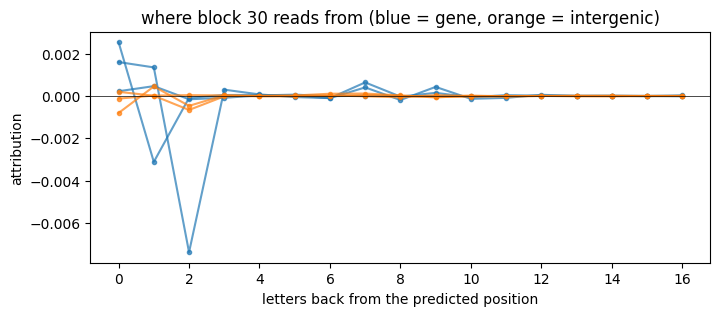

0      1      2    3    4    5    6      7    8    9  \
region     pos                                                                
gene       204001  0.003 -0.003 -0.000  0.0  0.0  0.0 -0.0  0.001 -0.0  0.0   
           305848  0.000  0.000 -0.000 -0.0  0.0  0.0 -0.0  0.000 -0.0 -0.0   
           399989  0.002  0.001 -0.007  0.0  0.0 -0.0 -0.0  0.000 -0.0  0.0   
intergenic 209630  0.000  0.000 -0.001 -0.0  0.0  0.0  0.0  0.000  0.0 -0.0   
           303820 -0.001  0.000 -0.000  0.0 -0.0 -0.0 -0.0  0.000  0.0 -0.0   
           399582 -0.000  0.000  0.000  0.0 -0.0  0.0  0.0 -0.000 -0.0  0.0   

                   ...   24   25   26   27   28   29   30   31   32  far(>64)  
region     pos     ...                                                         
gene       204001  ...  0.0  0.0 -0.0  0.0  0.0  0.0  0.0 -0.0 -0.0      -0.0  
           305848  ... -0.0 -0.0 -0.0 -0.0  0.0  0.0  0.0  0.0 -0.0       0.0  
           399989  ... -0.0 -0.0 -0.0 -0.0  0.0 -0.0 -0.0  0.0  0.0      -0.0  
intergenic 209630  ... -0.0 -0.0 -0.0 -0.0  0.0  0.0  0.0  0.0  0.0      -0.0  
           303820  ...  0.0  0.0  0.0  0.0 -0.0 -0.0  0.0 -0.0  0.0      -0.0  
           399582  ... -0.0  0.0 -0.0 -0.0 -0.0 -0.0  0.0 -0.0 -0.0      -0.0  

[6 rows x 34 columns]

In [15]:
dd = pd.DataFrame(dist_rows).set_index(['region', 'pos'])
near = dd[[c for c in dd.columns if isinstance(c, int) and c <= 16]]
plt.figure(figsize=(8, 3))
for (region, pos), row in near.iterrows():
    plt.plot(row.index, row.values, marker='o', ms=3, color='C0' if region == 'gene' else 'C1', alpha=0.7)
plt.axhline(0, color='k', lw=0.5); plt.xlabel('letters back from the predicted position')
plt.ylabel('attribution'); plt.title('where block 30 reads from (blue = gene, orange = intergenic)'); plt.show()
dd.round(3)

## R3.5 Where does a mutation's signal go?

For each depth, copy the mutated run's **entire residual** at the mutation site into the normal run. At depth −1 (the
letter itself) this is the mutated run exactly (fraction = 1). The depth where the fraction drops is where the model has
**moved the signal away from the mutated position** into later positions.

done 41256881
done 41256880
done 41219643
done 41215936
done 41219636


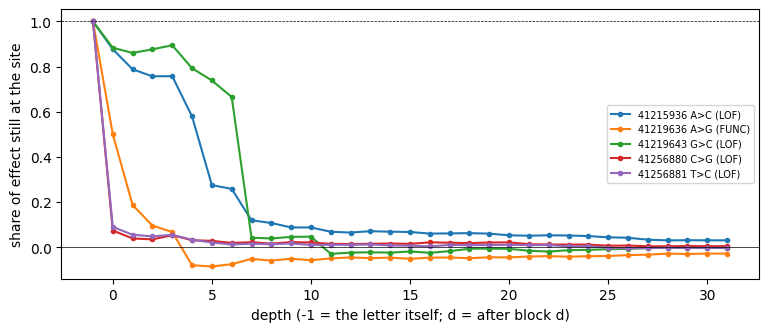

variant,41215936 A>C (LOF),41219636 A>G (FUNC),41219643 G>C (LOF),41256880 C>G (LOF),41256881 T>C (LOF)
depth,,,,,
-1,1.00,1.00,1.00,1.00,1.00
0,0.88,0.50,0.88,0.07,0.09
1,0.79,0.19,0.86,0.04,0.06
2,0.76,0.10,0.88,0.03,0.05
3,0.76,0.07,0.89,0.05,0.05
4,0.58,-0.08,0.79,0.03,0.03
5,0.28,-0.09,0.74,0.03,0.02
6,0.26,-0.08,0.67,0.02,0.01
7,0.12,-0.05,0.04,0.02,0.02


In [16]:
import gzip, os, urllib.request
for f in ['GRCh37.p13_chr17.fna.gz']:
    if not os.path.exists(f'data/{f}'):
        urllib.request.urlretrieve(f'{EVO2_RAW}/brca1/{f}', f'data/{f}')
with gzip.open('data/GRCh37.p13_chr17.fna.gz', 'rt') as h:
    chr17 = str(next(SeqIO.parse(h, 'fasta')).seq).upper()
# large-effect variants from round 2 (4 LOF + 1 FUNC with an unexpectedly large effect)
VARS = [(41256881, 'T', 'C', 'LOF'), (41256880, 'C', 'G', 'LOF'), (41219643, 'G', 'C', 'LOF'),
        (41215936, 'A', 'C', 'LOF'), (41219636, 'A', 'G', 'FUNC')]
depth_rows = []
for pos, ref, alt, cls in VARS:
    v = mh.make_variant(chr17, pos - 1, ref, alt, window=8192)
    rows = mh.variants.residual_patch_by_depth(hm, v, span=200)
    for r in rows:
        r.update(variant=f'{pos} {ref}>{alt} ({cls})')
    depth_rows += rows
    print('done', pos)
RESULTS['residual_depth'] = depth_rows
dr = pd.DataFrame(depth_rows)
plt.figure(figsize=(9, 3.5))
for name, g in dr.groupby('variant'):
    plt.plot(g['depth'], g['fraction'], marker='o', ms=3, label=name)
plt.axhline(1, color='k', lw=0.5, ls='--'); plt.axhline(0, color='k', lw=0.5)
plt.xlabel('depth (-1 = the letter itself; d = after block d)'); plt.ylabel('share of effect still at the site')
plt.legend(fontsize=7); plt.show()
dr.pivot(index='depth', columns='variant', values='fraction').round(2)

## R3.6 Block 0: are start/stop codons special?

1. Controlled detector counts for **all 64** three-letter words, ranked. Where do ATG, TAA, TAG and TGA land? Also
   checked: their reverse complements (CAT, TTA, CTA, TCA), which are the same signals on the other DNA strand.
2. **Total-effect** position importance, which catches channels that respond only to letter combinations (round 2's
   main-effect measure scored channel 263 as zero).

In [17]:
md_ = motifs.enumerate_block0(hm, keep_all=True)
ranks = motifs.rank_all_words(md_)
rk = {r['word']: r for r in ranks}
RESULTS['word_ranks'] = ranks
print('top 12 words by controlled detector channels:', [(r['word'], r['controlled']) for r in ranks[:12]])
for w in ['ATG', 'TAA', 'TAG', 'TGA', 'CAT', 'TTA', 'CTA', 'TCA', 'GCG', 'CCC']:
    print(f"{w}: rank {rk[w]['rank']:>2}/64, controlled {rk[w]['controlled']:>3}, raw {rk[w]['raw']:>3}")
cc = np.array([r['controlled'] for r in ranks])
print(f'median controlled count over 64 words: {np.median(cc):.0f}; mean {cc.mean():.1f}')

top 12 words by controlled detector channels: [('TAA', 65), ('GTG', 64), ('AAT', 63), ('CCT', 62), ('TTA', 61), ('ATA', 59), ('TGT', 59), ('AGA', 58), ('AAC', 57), ('CTC', 57), ('GGT', 57), ('TAT', 57)]
ATG: rank 31/64, controlled  46, raw  46
TAA: rank  1/64, controlled  65, raw 145
TAG: rank 26/64, controlled  50, raw  50
TGA: rank 48/64, controlled  41, raw  41
CAT: rank 51/64, controlled  39, raw  39
TTA: rank  5/64, controlled  61, raw 135
CTA: rank 19/64, controlled  53, raw  53
TCA: rank 60/64, controlled  25, raw  25
GCG: rank 20/64, controlled  53, raw  95
CCC: rank 63/64, controlled   8, raw 264
median controlled count over 64 words: 46; mean 45.2


mean TOTAL effect by position (8 back -> current): [0.075 0.102 0.156 0.166 0.17  0.205 0.301 0.264 0.309]
channels whose main-effect importance is ~0 everywhere: 724
channel 263 (round 2: zero main effect) total effect by position: [0. 0. 0. 0. 0. 0. 0. 0. 0.]
channels with >= 80% of total effect in the last 6 positions: 51.9%


/tmp/ipykernel_2469/3805632975.py:8: RuntimeWarning: invalid value encountered in divide
  late_te = te[-6:].sum(0) / te.sum(0)


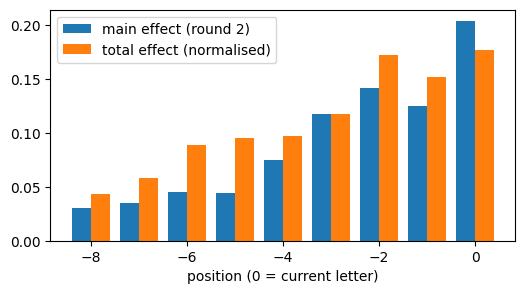

In [18]:
te = md_.position_total_effect          # (9, H)
main = md_.position_importance
prof_te = te.mean(1)
print('mean TOTAL effect by position (8 back -> current):', np.round(prof_te, 3))
print('channels whose main-effect importance is ~0 everywhere:', int((main.sum(0) < 1e-6).sum()))
if hm.hidden_size > 263:
    print('channel 263 (round 2: zero main effect) total effect by position:', np.round(te[:, 263], 3))
late_te = te[-6:].sum(0) / te.sum(0)
print(f'channels with >= 80% of total effect in the last 6 positions: {(late_te >= 0.8).mean():.1%}')
RESULTS['total_effect_profile'] = prof_te.tolist()
RESULTS['channel263_total_effect'] = te[:, 263].tolist() if hm.hidden_size > 263 else None
plt.figure(figsize=(6, 3))
plt.bar(np.arange(-8, 1) - 0.2, main.mean(1), width=0.4, label='main effect (round 2)')
plt.bar(np.arange(-8, 1) + 0.2, prof_te / prof_te.sum(), width=0.4, label='total effect (normalised)')
plt.xlabel('position (0 = current letter)'); plt.legend(); plt.show()

## Save

In [19]:
out = '/content/drive/MyDrive/marv_hyena_results_round3.json' if USE_DRIVE else 'results_round3.json'
with open(out, 'w') as f:
    json.dump(RESULTS, f, indent=1, default=float)
print('wrote', out)

wrote results_round3.json
